<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/Titanic_Klassifikation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

# Klassifikation mit logistischer Regression am Titanic-Datensatz

Nachdem wir in einem vorherigen Praktikum den Titanic-Datensatz erfolgreich vorbereitet haben (Imputation, Kodierung, Skalierung), wenden wir nun ein erstes Klassifikationsmodell an: **Logistische Regression**.

Ziel ist es, vorherzusagen, **ob eine Person den Schiffsuntergang überlebt hat oder nicht** – basierend auf ihren Merkmalen (Alter, Klasse, Geschlecht, etc.). Dies ist ein typisches **binäres Klassifikationsproblem**, da die Zielgröße (`lebendig`) zwei Werte annehmen kann:

Zielvariable:
- `1`: Person hat überlebt
- `0`: Person ist gestorben

In dieser Übung lernen Sie:
- wie man Trainings- und Testdaten erstellt,
- wie man ein logistisches Regressionsmodell mit `scikit-learn` trainiert,
- wie man die Vorhersagegenauigkeit (Accuracy) misst,
- und wie man die Leistung eines Modells mit Hilfe eines **Classification Reports** besser einschätzt.



---



Klassifikation, weil es nur 2 mögliche Antworten gibt.

* Imputation = fehlende Werte ergänzen (z.B. bei manchen Passagieren ist das Alter unbekannt)
* Kodierung = Text in Zahlen umwandeln (z.B. "männlich" → 0, "weiblich" → 1, weil Modelle nur mit Zahlen rechnen können)
* Skalierung = Werte in ähnliche Größenordnungen bringen (damit "Alter: 80" nicht mehr Gewicht bekommt als "Klasse: 3")


---



Wir gehen zuerst die Schritte der **Datenvorverarbeitung** für den Titanic Datensatz nochmal durch.
Dies ist im Wesentlichen eine Wiederholung der Aufgaben aus dem vorherigen Arbeitsblatt.

## Daten laden

Zunächst müssen wir die Daten laden. Als Datenstruktur bietet sich dafür ein Pandas DataFrame an.
mit `pandas.read_csv()` können wir eine CSV-Datei aus dem Internet direkt in ein DataFrame Objekt laden.

In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/fhswf/datasets/refs/heads/main/Titanic_de.csv"
df=pd.read_csv(url)
df

,ueberlebt,geschlecht,alter,geschwister_ehepartner,eltern_kinder,fahrpreis,klasse,erwachsener_mann,deck,hafen,allein
0,0,maennlich,22.0,1,0,7.2500,Dritte,True,NaN,Southampton,False
1,1,weiblich,38.0,1,0,71.2833,Erste,False,C,Cherbourg,False
2,1,weiblich,26.0,0,0,7.9250,Dritte,False,NaN,Southampton,True
3,1,weiblich,35.0,1,0,53.1000,Erste,False,C,Southampton,False
4,0,maennlich,35.0,0,0,8.0500,Dritte,True,NaN,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,maennlich,27.0,0,0,13.0000,Zweite,True,NaN,Southampton,True
887,1,weiblich,19.0,0,0,30.0000,Erste,False,B,Southampton,True
888,0,weiblich,NaN,1,2,23.4500,Dritte,False,NaN,Southampton,False
889,1,maennlich,26.0,0,0,30.0000,Erste,True,C,Cherbourg,True


## Fehlende Werte kompensieren
Wir wenden den **`SimpleImputer`** aus dem Modul `sklearn.impute` ann um die fehlenden Werte mit dem Mittelwert (numerische Features) oder dem Modus (kategorische Features) zu ersetzen.

In [2]:
from sklearn.impute import SimpleImputer

num_cols = ["alter", "fahrpreis"] #numerische daten
cat_cols = ["klasse", "deck", "hafen"] #kategorische daten

num_imputer = SimpleImputer(strategy="mean") #speicher imputer in num_imputer / mean = mittelwert
df[num_cols] = num_imputer.fit_transform(df[num_cols]) #holt aus dem dataframe nur die spalten num_cols. /  fit = schaut sich die daten an und brechnet den mittelwert und füllt mit transform alle lücken auf

cat_imputer = SimpleImputer(strategy="most_frequent") #most_frequent = Fülle mit dem häufigsten Wert auf
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

## Ordinale Features kodieren
Wir weisen den **ordinalen Features** umerische Werte zu.

In [3]:
# Direkte Umkodierung der kategorischen ordinalen Merkmale
df["geschlecht"] = df["geschlecht"].map({"weiblich": 0, "maennlich": 1})
df["klasse"] = df["klasse"].map({"Erste": 0, "Zweite": 1, "Dritte": 2})

# Boolesche Spalten in 0/1 umwandeln
df["erwachsener_mann"] = df["erwachsener_mann"].astype(int)
df["allein"] = df["allein"].astype(int)

## Nominale Features kodieren
Neben ordinalen Merkmalen enthält der Titanic-Datensatz auch eine Reihe **nominaler Merkmale**, d. h. Merkmale **ohne natürliche Reihenfolge**. Für diese Features verwenden wir das **One-Hot-Encoding**.

In [4]:
nominal_features = ["deck", "hafen"]

df = pd.get_dummies(df, columns=nominal_features, drop_first=True, dtype=int) #wandel nur deck und hafen um / dtype int = ganze zahlen 0 und 1

drop_first=True ⚠️ wichtig!

Bedeutet: "Lass die erste Kategorie weg"
Beispiel beim Hafen: Du bekommst nur hafen_Queenstown und hafen_Southampton – hafen_Cherbourg fehlt!
Warum? Weil man Cherbourg trotzdem erkennt: Wenn Queenstown=0 und Southampton=0, dann muss es ja Cherbourg sein. Die Spalte wäre redundant (= überflüssig). Diese Redundanz kann Modelle sogar verwirren (Stichwort: "Dummy-Variable-Falle").

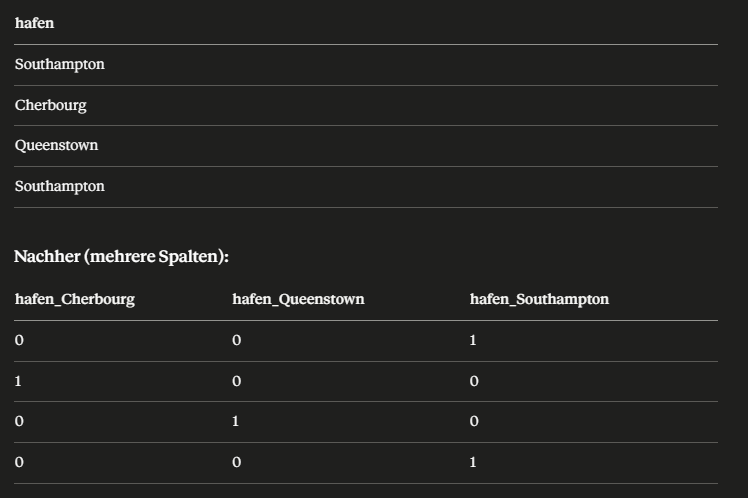

## Aufteilen in Trainings- und Testdaten

Damit wir die Leistung des Modells realistisch bewerten können, teilen wir die vorhandenen Daten in zwei Teile:

- **Trainingsdaten** (z. B. 70 %): für das Modelltraining
- **Testdaten** (z. B. 30 %): für die Bewertung

Diese Aufteilung erfolgt zufällig, aber durch Angabe eines festen `random_state` stellen wir sicher, dass die Ergebnisse reproduzierbar bleiben.

In [5]:
from sklearn.model_selection import train_test_split

# Zielvariable und Merkmalsmatrix definieren
y = df["ueberlebt"] # zielvariable
X = df.drop(columns=["ueberlebt"]) #nimm die tabelle und lösche überlebt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Standardisierung
Für die Numerischen Merkmale `alter` und `fahrpreis`, die **sehr unterschiedliche Wertebereiche** haben, wenden wir nun noch die **Standardisierung** an.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[["alter", "fahrpreis"]] = scaler.fit_transform(X_train[["alter", "fahrpreis"]]) # merke mittelwert und standardabweichung
X_test[["alter", "fahrpreis"]] = scaler.transform(X_test[["alter", "fahrpreis"]]) # wende sie an die testdaten an

## Klassifikation mit logistischer Regression

**Aufgabe:** Verwenden Sie das Modell `LogisticRegression` aus dem Modul `sklearn.linear_model` um ein Vorhersagemodell für die Überlebenden der Titanic Katestrophe aufzustellen.


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


## Bewertung des Modells

**Aufgabe:** Messen Sie die **Accuracy**, also den Anteil der korrekt klassifizierten Fälle in den Testdaten, für Ihr Modell auf Basis der Testdaten. Verwenden Sie dann den **Classification Report** aus dem Modul `sklearn.metrics`, um weitere Metriken auszugeben.

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8208955223880597
